### Clean HRRR-AK NetCDF Files and Select Point Simulation Locations

Notebook contents 
* We processed with grib files from folders in `1_process_hrrrak_grib_files` and now we need to do some cleaning and save cleaned netcdfs
* When we created the netcdfs, we did not fix the dimensions and crs, so I am doing that here then resaving the file

created by Cassie Lumbrazo\
last updated: Feb 2026\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

import geopandas as gpd
from shapely.geometry import Point

In [2]:
import xarray as xr
import geopandas as gpd
from shapely.geometry import Point
import rioxarray  # For CRS handling

In [3]:
pwd

'/home/cassie/python/repos/snow_model_forcing/large_juneau_domain'

## Load HRRR-AK UTM NetCDF

In [4]:
# Path to the NetCDF file
utm_output_path = "/hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_merged_grib_f567_WY2024_utm.nc"

# Open the NetCDF dataset
ds = xr.open_dataset(utm_output_path)

# Check the CRS (it might be None if not properly embedded)
print(f"Loaded CRS: {ds.rio.crs}")

# If CRS is None, assign it manually (since it was reprojected to EPSG:32608)
if ds.rio.crs is None:
    ds.rio.write_crs("EPSG:32608", inplace=True)
    print("Assigned CRS: EPSG:32608")

# Now the dataset has the CRS set
print(f"Final CRS: {ds.rio.crs}")

Loaded CRS: None
Assigned CRS: EPSG:32608
Final CRS: EPSG:32608


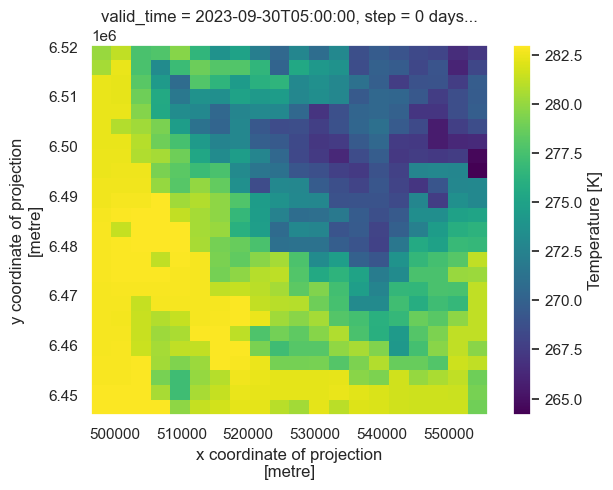

In [5]:
ds.temp_surface[0].plot()

So that looks great, now the crs is actually set, reporjected to utm, and the data can be easily used. 

## Check datetime timeseries

In [6]:
ds

<xarray.Dataset> Size: 987MB
Dimensions:       (time: 8807, y: 25, x: 20)
Coordinates:
    valid_time    (time) datetime64[ns] 70kB ...
    step          (time) timedelta64[ns] 70kB ...
  * time          (time) datetime64[ns] 70kB 2023-09-30T05:00:00 ... 2024-10-...
  * y             (y) float64 200B 6.519e+06 6.516e+06 ... 6.45e+06 6.447e+06
  * x             (x) float64 160B 4.98e+05 5.009e+05 ... 5.514e+05 5.544e+05
    spatial_ref   int64 8B 0
Data variables: (12/28)
    gust          (time, y, x) float64 35MB ...
    pressure      (time, y, x) float64 35MB ...
    orog          (time, y, x) float64 35MB ...
    temp_surface  (time, y, x) float64 35MB ...
    swe           (time, y, x) float64 35MB ...
    snowdepth     (time, y, x) float64 35MB ...
    ...            ...
    swrad         (time, y, x) float64 35MB ...
    lwrad         (time, y, x) float64 35MB ...
    suswrf        (time, y, x) float64 35MB ...
    sulwrf        (time, y, x) float64 35MB ...
    wind          (time, y, x) float64 35MB ...
    wind_dir      (time, y, x) float64 35MB ...
Attributes:
    long_name:       Wind speed (gust)
    units:           m s**-1
    GRIB_shortName:  gust
    GRIB_name:       Wind speed (gust)
    GRIB_cfName:     unknown
    GRIB_cfVarName:  gust
    level:           0
    typeOfLevel:     surface

In [7]:
# print the first few rows of 'time'
print(ds.time.values[:10])

['2023-09-30T05:00:00.000000000' '2023-09-30T06:00:00.000000000'
 '2023-09-30T07:00:00.000000000' '2023-09-30T08:00:00.000000000'
 '2023-09-30T09:00:00.000000000' '2023-09-30T10:00:00.000000000'
 '2023-09-30T11:00:00.000000000' '2023-09-30T12:00:00.000000000'
 '2023-09-30T13:00:00.000000000' '2023-09-30T14:00:00.000000000']


## So, we are in UTM Zone 8N (EPSG:32608)
Now to get the lat/lon point locations for each site, 

we need to project the lat/lon for those locations (which are in WGS84) into EPSG:3268, and select the nearest gridcell

In [8]:
# lat_ppsa2, lon_ppsa2 = 58.26200, -134.51700
# lat_tram, lon_tram = 58.2971, -134.386
# lat_heen, lon_heen = 58.69652, -134.86448
# lat_tkg4, lon_tkg4 = 58.63447,-134.237

In [9]:
# Path to the UTM NetCDF file
utm_output_path = "/hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_merged_grib_f567_WY2024_utm.nc"

# Load the dataset
ds_utm = xr.open_dataset(utm_output_path)

# Assign CRS if not set
if ds_utm.rio.crs is None:
    ds_utm.rio.write_crs("EPSG:32608", inplace=True)

# Site coordinates (lat/lon, WGS84)
sites = {
    "ppsa2": {"lat": 58.26200, "lon": -134.51700},
    "tram": {"lat": 58.2971, "lon": -134.386},
    "heen": {"lat": 58.69652, "lon": -134.86448},
    "tkg4": {"lat": 58.63447, "lon": -134.237}
}

# Function to extract nearest grid cell for a site
def extract_site_data(ds, site_name, lat, lon):
    # Create GeoDataFrame for the site
    gdf_site = gpd.GeoDataFrame({
        "site": [site_name],
        "geometry": [Point(lon, lat)]
    }, crs="EPSG:4326")
    
    # Convert to UTM (same as dataset)
    gdf_site_proj = gdf_site.to_crs("EPSG:32608")
    x_site, y_site = gdf_site_proj.geometry[0].x, gdf_site_proj.geometry[0].y
    
    # Select nearest grid cell
    ds_site = ds.sel(x=x_site, y=y_site, method="nearest")
    
    # Add site info as attributes
    ds_site.attrs.update({
        "site_name": site_name,
        "original_lat": lat,
        "original_lon": lon,
        "utm_x": x_site,
        "utm_y": y_site
    })
    
    return ds_site

# Process each site
for site_name, coords in sites.items():
    ds_site = extract_site_data(ds_utm, site_name, coords["lat"], coords["lon"])
    
    # Save to NetCDF
    output_path = f"/hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_f567_WY2024_utm_site_{site_name}.nc"
    ds_site.to_netcdf(output_path)
    print(f"📁 Saved site data for {site_name} to {output_path}")

print("✅ All site extractions completed!")

📁 Saved site data for ppsa2 to /hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_f567_WY2024_utm_site_ppsa2.nc
📁 Saved site data for tram to /hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_f567_WY2024_utm_site_tram.nc
📁 Saved site data for heen to /hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_f567_WY2024_utm_site_heen.nc
📁 Saved site data for tkg4 to /hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_f567_WY2024_utm_site_tkg4.nc
✅ All site extractions completed!


# Plot the Sites

### First, as a map

In [10]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

Text(0.5, 1.0, 'HRRR temp (single timestep) with site locations')

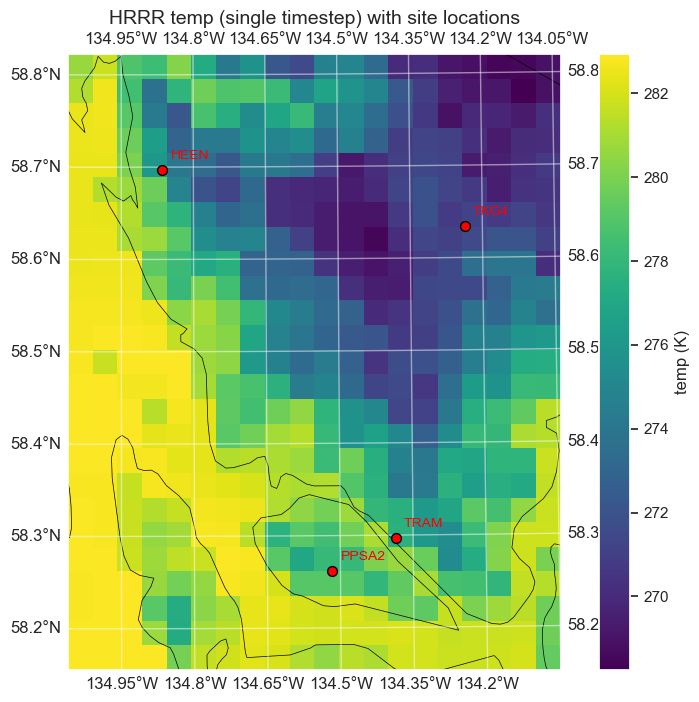

In [11]:
# Site coordinates (lat/lon, WGS84)
sites = {
    "ppsa2": {"lat": 58.26200, "lon": -134.51700},
    "tram": {"lat": 58.2971, "lon": -134.386},
    "heen": {"lat": 58.69652, "lon": -134.86448},
    "tkg4": {"lat": 58.63447, "lon": -134.237}
}

# Create GeoDataFrame for sites
gdf_sites = gpd.GeoDataFrame({
    "site": list(sites.keys()),
    "geometry": [Point(sites[site]["lon"], sites[site]["lat"]) for site in sites]
}, crs="EPSG:4326")

# Convert sites to UTM (same as dataset)
gdf_sites_utm = gdf_sites.to_crs("EPSG:32608")

# Select a variable for background (e.g., temp at first time step)
var_name = 'temp'  # Change to any variable, e.g., 'temp', 'precip_total'
background_data = ds_utm[var_name].isel(time=0)  # First time step

# Plot setup
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.UTM(8)})  # UTM Zone 8N

# Plot the background raster
background_data.plot(ax=ax, cmap='viridis', add_colorbar=True, cbar_kwargs={'label': f'{var_name} ({background_data.attrs.get("units", "")})'})

# Add coastlines and features for context
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.gridlines(draw_labels=True, alpha=0.5)

# Plot site points
for idx, row in gdf_sites_utm.iterrows():
    x, y = row.geometry.x, row.geometry.y
    ax.scatter(x, y, color='red', s=50, edgecolor='black', zorder=5)
    ax.text(x + 1000, y + 1000, row['site'].upper(), fontsize=10, color='red', ha='left', va='bottom', zorder=6)

# Set title
ax.set_title(f"HRRR {var_name} (single timestep) with site locations", fontsize=14)

# # Save or show the plot
# plt.tight_layout()
# plt.savefig("/hdd/snow_hydrology/hrrrak/large_juneau_domain/plots/hrrr_temp_sites_map.png", dpi=300)
# plt.show()

# print("✅ Map plotted and saved!")

### Plot Timeseries to Compare

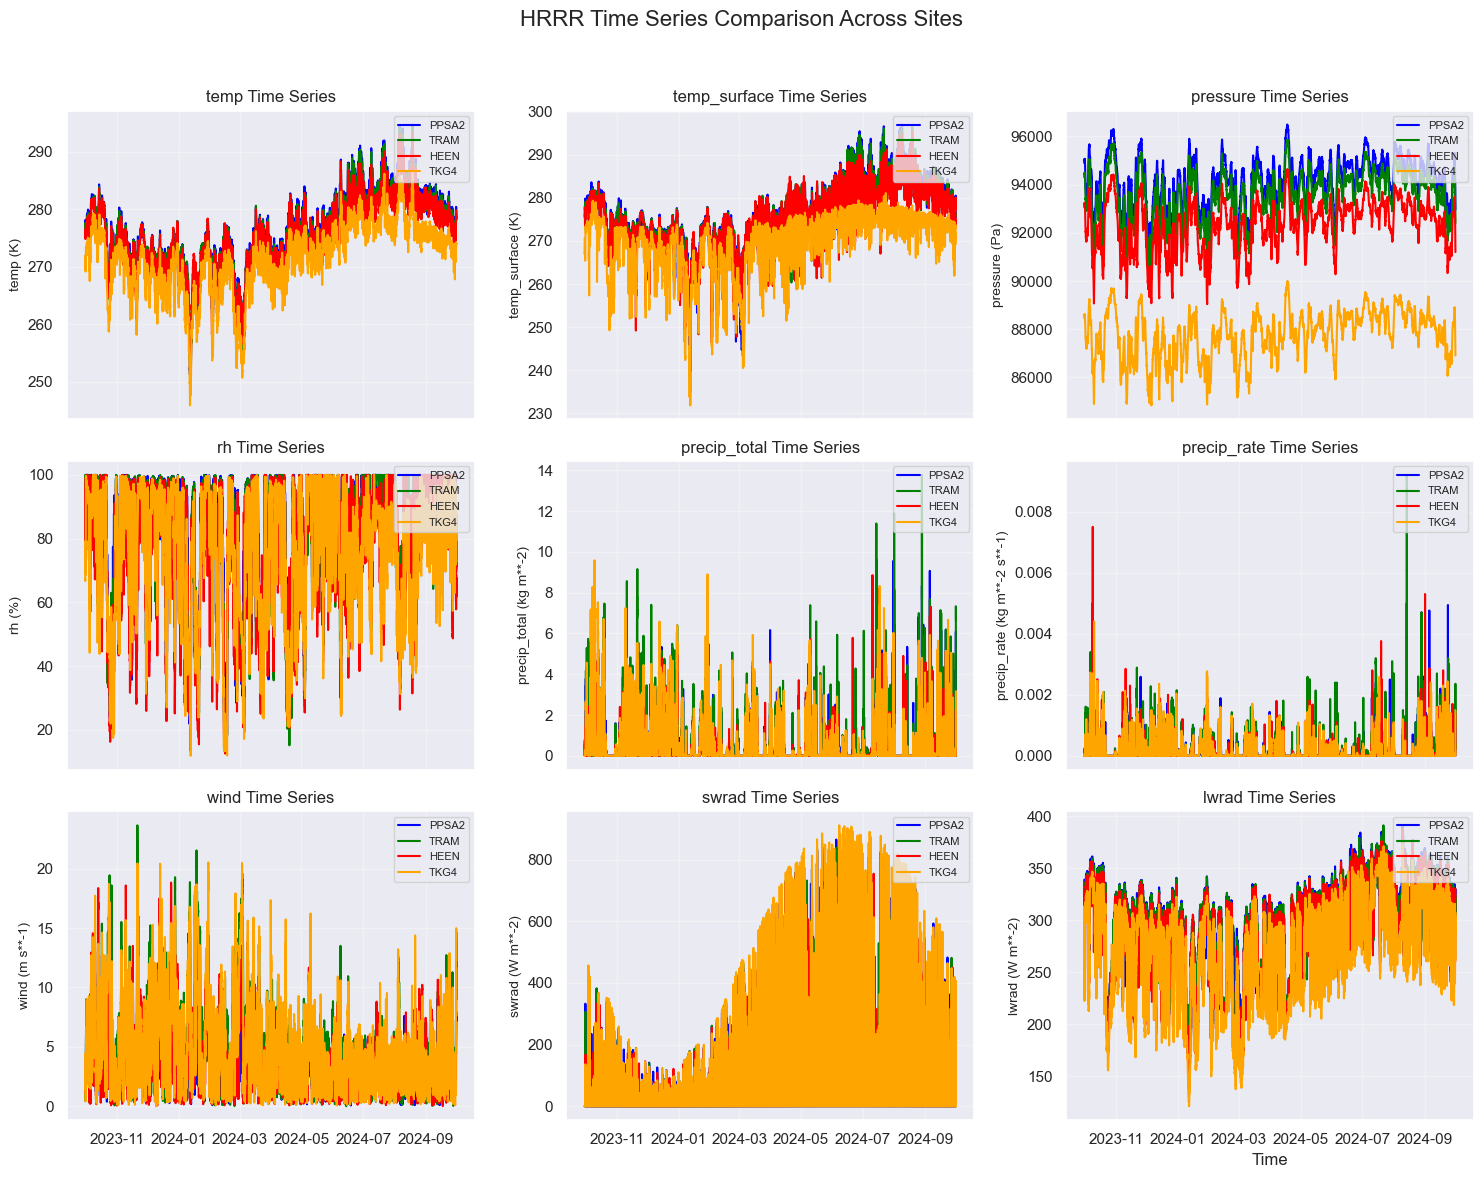

In [12]:
# Paths to site NetCDFs (assuming they were saved as per previous code)
site_files = {
    "ppsa2": "/hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_f567_WY2024_utm_site_ppsa2.nc",
    "tram": "/hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_f567_WY2024_utm_site_tram.nc",
    "heen": "/hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_f567_WY2024_utm_site_heen.nc",
    "tkg4": "/hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_f567_WY2024_utm_site_tkg4.nc"
}

# Load datasets
site_ds = {}
for site, path in site_files.items():
    ds = xr.open_dataset(path)
    site_ds[site] = ds

# Variables to plot (important for modeling)
variables = ['temp', 'temp_surface', 'pressure', 'rh', 'precip_total', 'precip_rate', 'wind', 'swrad', 'lwrad']

# Colors for sites
colors = {'ppsa2': 'blue', 'tram': 'green', 'heen': 'red', 'tkg4': 'orange'}

# Create subplots (3x3 grid for 9 variables)
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True)
axes = axes.flatten()  # Flatten for easy indexing

for i, var in enumerate(variables):
    ax = axes[i]
    for site, ds in site_ds.items():
        if var in ds:
            data = ds[var]
            # Convert to pandas for easier plotting (if needed)
            time = pd.to_datetime(ds['time'].values)
            ax.plot(time, data.values, label=site.upper(), color=colors[site], linewidth=1.5)
    
    ax.set_title(f"{var} Time Series", fontsize=12)
    ax.set_ylabel(f"{var} ({ds[var].attrs.get('units', '')})", fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

# Set common x-label
axes[-1].set_xlabel("Time", fontsize=12)  # Bottom-right subplot

# Overall title
fig.suptitle("HRRR Time Series Comparison Across Sites", fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle

# # Save the plot
# output_plot = "/hdd/snow_hydrology/hrrrak/large_juneau_domain/plots/hrrr_sites_timeseries_comparison.png"
# plt.savefig(output_plot, dpi=300)

plt.show()

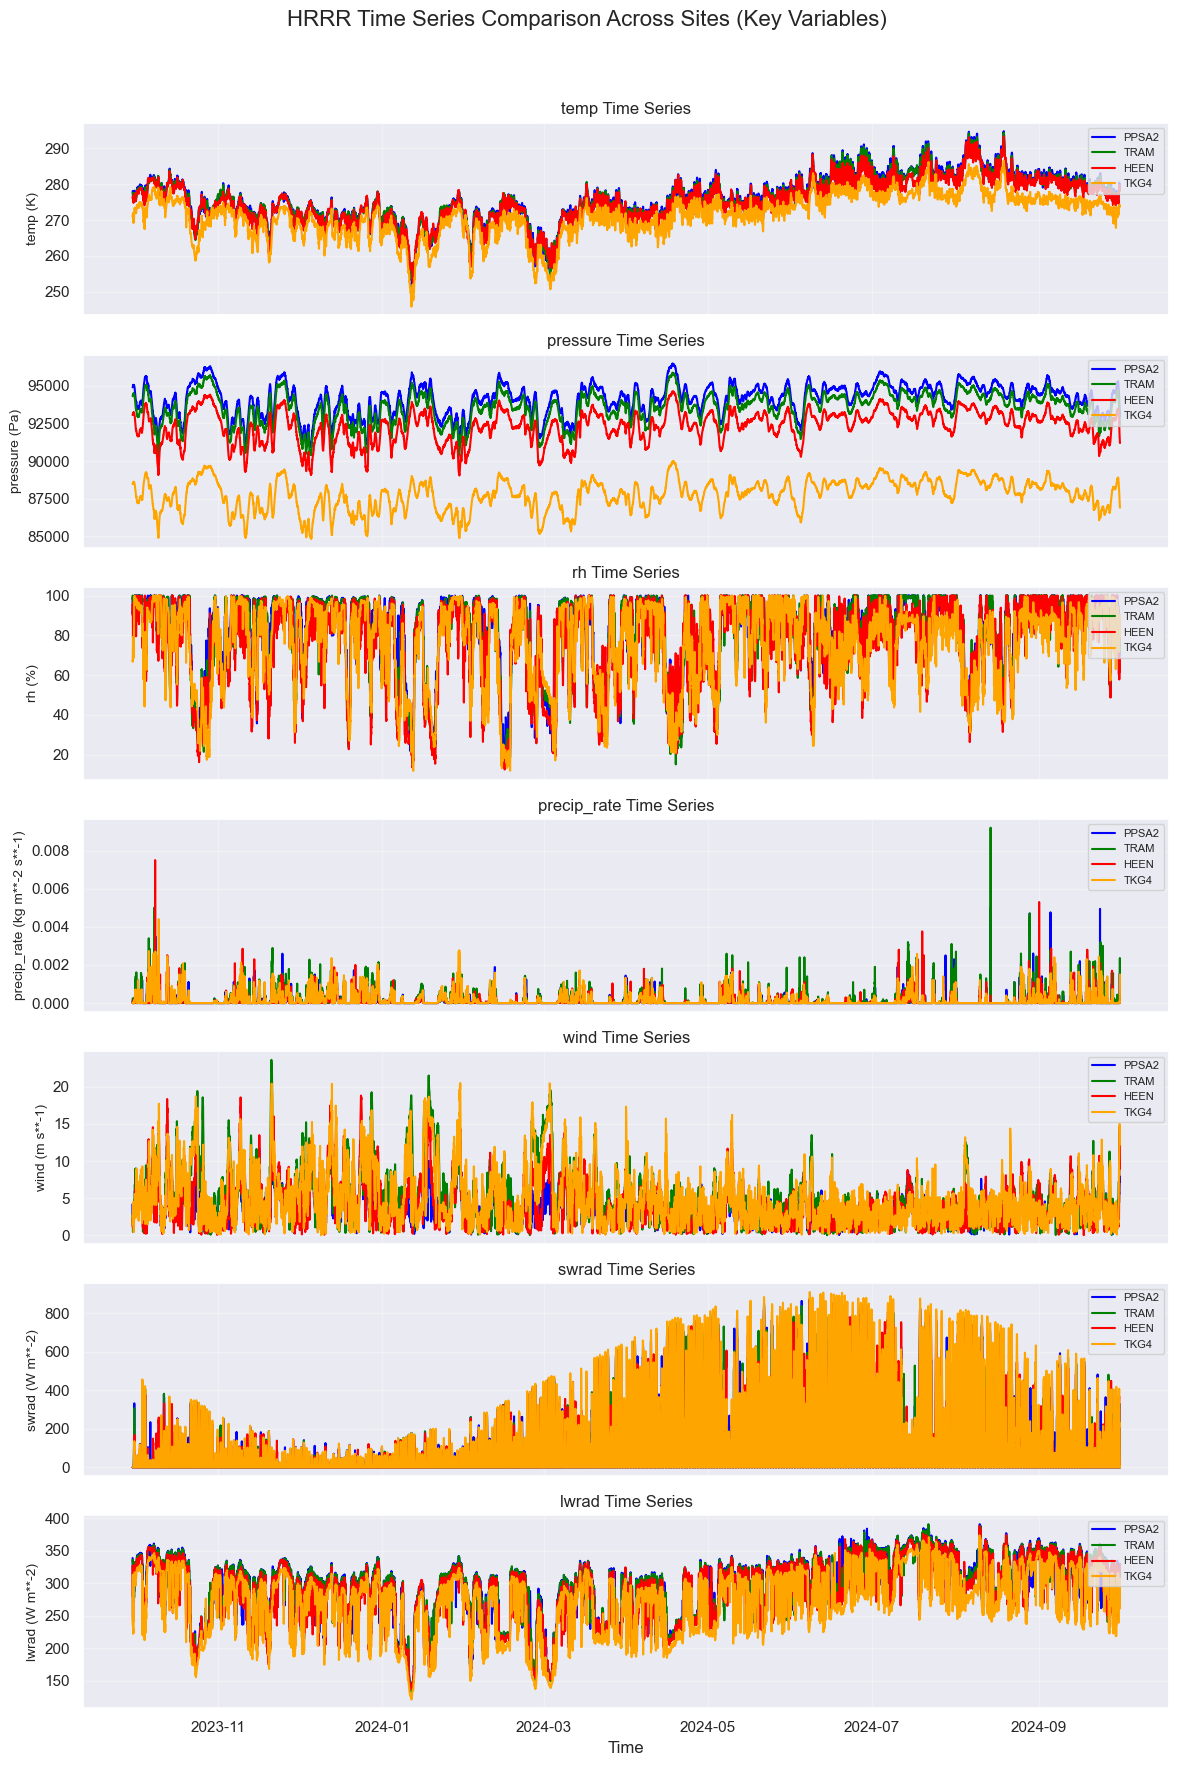

In [13]:
# Variables to plot (subset for modeling)
variables = ['temp', 'pressure', 'rh', 'precip_rate', 'wind', 'swrad', 'lwrad']

# Colors for sites
colors = {'ppsa2': 'blue', 'tram': 'green', 'heen': 'red', 'tkg4': 'orange'}

# Create subplots (7 rows, 1 column for wider plots)
fig, axes = plt.subplots(7, 1, figsize=(12, 18), sharex=True)  # Wider and taller

for i, var in enumerate(variables):
    ax = axes[i]
    for site, ds in site_ds.items():
        if var in ds:
            data = ds[var]
            time = pd.to_datetime(ds['time'].values)
            ax.plot(time, data.values, label=site.upper(), color=colors[site], linewidth=1.5)
    
    ax.set_title(f"{var} Time Series", fontsize=12)
    ax.set_ylabel(f"{var} ({ds[var].attrs.get('units', '')})", fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

# Set common x-label on the last subplot
axes[-1].set_xlabel("Time", fontsize=12)

# Overall title
fig.suptitle("HRRR Time Series Comparison Across Sites (Key Variables)", fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()